# **Experiment Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [ ]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT1"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

print("###### Install required Python packages ######")
! pip install -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}


###### Install required Python packages ######

###### Connect to personal Google Drive ######
Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT1/data
/content/gdrive/MyDrive/36106/assignment/AT1/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.d Import Packages

In [ ]:
import pandas as pd
import altair as alt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---
## A. Data Understanding

### A.1   Load Datasets

> Do not change this code

In [ ]:
# Load training data
training_df = pd.read_csv(folder_path / "rental_training.csv")

In [ ]:
# Load validation data
validation_df = pd.read_csv(folder_path / "rental_validation.csv")

In [ ]:
# Load testing data
testing_df = pd.read_csv(folder_path / "rental_testing.csv")

### A.2 Explore Training Set

> You can add more cells in this section

In [ ]:
training_df.head(100)

,advertised_date,number_of_bedrooms,rent,floor_area,level,suburb,furnished,tenancy_preference,number_of_bathrooms,point_of_contact,secondary_address,building_number,street_name,street_suffix,prefix,first_name,last_name,gender,phone_number,email
0,2022-05-18,2,568.0,1100,Ground out of 2,Canberra,Unfurnished,Bachelors/Family,2,Contact Owner,02/,1,Mcdowell Edge,Driveway,Mr.,Robert,Jones,m,(08) 8174 5701,georgelopez@example.org
1,2022-05-13,2,581.0,800,1 out of 3,Canberra,Semi-Furnished,Bachelors/Family,1,Contact Owner,667/,6,Lewis Parkway,Viaduct,Mrs.,Lisa,Mcknight,f,(08).5553.7944,robertdorsey@example.net
2,2022-05-16,2,577.0,1000,1 out of 3,Canberra,Semi-Furnished,Bachelors/Family,1,Contact Owner,859/,459,Daniel Copse,Meander,NaN,Annette,Lester,u,(03).6394.3934,rodriguezkaren@example.net
3,2022-05-09,2,565.0,850,1 out of 2,Canberra,Unfurnished,Bachelors,1,Contact Owner,Flat 54,482,Young Walkway,Firetrail,Mrs.,Emma,Hill,f,+61836311377,johnsonjeremy@example.com
4,2022-04-29,2,564.0,600,Ground out of 1,Canberra,Unfurnished,Bachelors/Family,2,Contact Owner,Unit 75,838,Michael Port,Esplanade,Miss,Ariana,Richardson,f,+61 409 341 340,sbrown@example.net
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-05-21,1,565.0,300,1 out of 3,Canberra,Semi-Furnished,Bachelors,1,Contact Agent,810/,9,Shawn Gardens,Tollway,NaN,Christy,Hudson,u,9637-1692,annakaiser@example.org
96,2022-04-28,3,574.0,1600,1 out of 3,Canberra,Unfurnished,Bachelors/Family,2,Contact Owner,330/,1,Sara Street,Riviera,NaN,Eric,Young,u,4972 2517,shepardgregory@example.com
97,2022-05-15,2,573.0,1000,1 out of 3,Canberra,Unfurnished,Bachelors/Family,2,Contact Owner,3/,202,Brooke Plateau,Grange,Mrs.,Alyssa,Henry,f,+61389078205,hannahperez@example.net
98,2022-05-30,1,562.0,20,2 out of 3,Canberra,Unfurnished,Bachelors/Family,1,Contact Owner,Suite 143,93,Montoya Underpass,Park,NaN,Breanna,Davis,u,+61 439 668 379,karen82@example.com


In [ ]:
training_df.shape

(3434, 20)

In [ ]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3434 entries, 0 to 3433
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   advertised_date      3434 non-null   object 
 1   number_of_bedrooms   3434 non-null   int64  
 2   rent                 3434 non-null   float64
 3   floor_area           3434 non-null   int64  
 4   level                3434 non-null   object 
 5   suburb               3434 non-null   object 
 6   furnished            3434 non-null   object 
 7   tenancy_preference   3434 non-null   object 
 8   number_of_bathrooms  3434 non-null   int64  
 9   point_of_contact     3434 non-null   object 
 10  secondary_address    3434 non-null   object 
 11  building_number      3434 non-null   int64  
 12  street_name          3434 non-null   object 
 13  street_suffix        3434 non-null   object 
 14  prefix               2274 non-null   object 
 15  first_name           3434 non-null   o

In [ ]:
training_df.describe()

,number_of_bedrooms,rent,floor_area,number_of_bathrooms,building_number
count,3434.000000,3434.000000,3434.000000,3434.000000,3434.000000
mean,2.022423,595.080664,919.708794,1.881188,189.853815
std,0.813388,105.380805,588.741127,0.850203,284.860733
min,1.000000,557.000000,20.000000,1.000000,0.000000
25%,1.000000,567.000000,550.000000,1.000000,7.000000
50%,2.000000,574.000000,800.000000,2.000000,46.000000
75%,2.000000,590.000000,1186.000000,2.000000,268.750000
max,6.000000,5037.000000,8000.000000,10.000000,998.000000


In [ ]:
training_df.describe(include='object')

,advertised_date,level,suburb,furnished,tenancy_preference,point_of_contact,secondary_address,street_name,street_suffix,prefix,first_name,last_name,gender,phone_number,email
count,3434,3434,3434,3434,3434,3434,3434,3434,3434,2274,3434,3433,3434,3434,3434
unique,66,334,6,3,3,3,1381,3373,200,5,701,1085,3,3434,3411
top,2022-05-12,1 out of 2,Brisbane,Semi-Furnished,Bachelors/Family,Contact Owner,8/,Michael Run,Retreat,Mr.,Michael,Smith,u,+61 487 589 767,usmith@example.org
freq,149,289,694,1587,2579,2555,54,3,29,789,66,68,1160,1,2


In [ ]:
training_df.duplicated().sum()

np.int64(0)

### A.3 Explore Validation Set

> You can add more cells in this section

In [ ]:
validation_df.head(100)

,advertised_date,number_of_bedrooms,rent,floor_area,level,suburb,furnished,tenancy_preference,number_of_bathrooms,point_of_contact,secondary_address,building_number,street_name,street_suffix,prefix,first_name,last_name,gender,phone_number,email
0,2022-06-13,2,571.0,560,Ground out of 1,Melbourne,Semi-Furnished,Family,2,Contact Owner,Level 1,1,Baldwin Towers,Footway,NaN,Jay,Glover,u,(03)08687820,brettkennedy@example.net
1,2022-06-04,2,683.0,750,Upper Basement out of 30,Sydney,Unfurnished,Bachelors/Family,2,Contact Agent,1/,31,Cox Fire Track,Lookout,Dr.,Danielle,Tran,f,(03)-0313-6072,dana35@example.net
2,2022-04-29,3,574.0,950,Ground out of 3,Adelaide,Unfurnished,Bachelors/Family,2,Contact Owner,Unit 37,89,Davidson Ground,Part,NaN,Ashley,Pacheco,u,08-9358-6662,justin89@example.org
3,2022-05-18,1,565.0,500,2 out of 2,Sydney,Semi-Furnished,Bachelors,1,Contact Owner,16/,82,Fitzpatrick Key,Heights,NaN,Victoire,Weber,u,(02).9817.8199,pruittmichael@example.net
4,2022-04-28,2,565.0,600,2 out of 3,Brisbane,Semi-Furnished,Bachelors/Family,2,Contact Owner,Flat 64,9,Heidi Access,Mews,Mrs.,Kerry,Koch,f,4124.0210,hansendiana@example.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-05-01,2,569.0,1100,Ground out of 5,Perth,Unfurnished,Bachelors/Family,2,Contact Owner,48/,398,Perkins Basin,Alleyway,Miss,Deanna,Fitzpatrick,f,5312-6590,tpatterson@example.org
96,2022-06-21,3,645.0,2780,4 out of 26,Perth,Semi-Furnished,Bachelors/Family,3,Contact Agent,Level 4,0,Lonnie Terrace,Highway,NaN,Jack,Mccoy,u,0481-593-709,barry42@example.org
97,2022-06-08,3,574.0,900,1 out of 3,Adelaide,Furnished,Bachelors/Family,3,Contact Owner,Flat 65,467,Sarah Motorway,Crest,Dr.,Eric,White,m,0400-047-552,stacey02@example.net
98,2022-05-30,2,567.0,805,1 out of 2,Melbourne,Semi-Furnished,Bachelors/Family,2,Contact Owner,Apt. 364,0,Jose Square,Ride,NaN,James,Duncan,u,0609-2453,emily79@example.com


In [ ]:
validation_df.shape

(1320, 20)

In [ ]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   advertised_date      1320 non-null   object 
 1   number_of_bedrooms   1320 non-null   int64  
 2   rent                 1320 non-null   float64
 3   floor_area           1320 non-null   int64  
 4   level                1320 non-null   object 
 5   suburb               1320 non-null   object 
 6   furnished            1320 non-null   object 
 7   tenancy_preference   1320 non-null   object 
 8   number_of_bathrooms  1320 non-null   int64  
 9   point_of_contact     1320 non-null   object 
 10  secondary_address    1320 non-null   object 
 11  building_number      1320 non-null   int64  
 12  street_name          1320 non-null   object 
 13  street_suffix        1320 non-null   object 
 14  prefix               855 non-null    object 
 15  first_name           1320 non-null   o

In [ ]:
validation_df.describe()

,number_of_bedrooms,rent,floor_area,number_of_bathrooms,building_number
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,2.091667,596.413636,959.723485,1.946212,189.813636
std,0.819543,67.974174,645.170039,0.879891,283.228988
min,1.000000,557.000000,10.000000,1.000000,0.000000
25%,2.000000,568.000000,550.000000,1.000000,6.000000
50%,2.000000,574.000000,825.500000,2.000000,49.000000
75%,3.000000,594.000000,1200.000000,2.000000,270.000000
max,6.000000,1451.000000,6000.000000,7.000000,996.000000


In [ ]:
validation_df.describe(include='object')

,advertised_date,level,suburb,furnished,tenancy_preference,point_of_contact,secondary_address,street_name,street_suffix,prefix,first_name,last_name,gender,phone_number,email
count,1320,1320,1320,1320,1320,1320,1320,1320,1320,855,1320,1319,1320,1320,1320
unique,72,199,6,3,3,2,710,1310,199,5,469,667,3,1320,1317
top,2022-07-04,1 out of 2,Sydney,Semi-Furnished,Bachelors/Family,Contact Owner,8/,Jones Trunkway,Freeway,Mr.,Robert,Smith,u,8233 8936,qgomez@example.org
freq,110,109,247,585,944,927,25,3,15,289,24,24,465,1,2


In [ ]:
validation_df.duplicated().sum()

np.int64(0)

### A.4 Explore Testing Set

> You can add more cells in this section

In [ ]:
testing_df.head(100)

,advertised_date,number_of_bedrooms,rent,floor_area,level,suburb,furnished,tenancy_preference,number_of_bathrooms,point_of_contact,secondary_address,building_number,street_name,street_suffix,prefix,first_name,last_name,gender,phone_number,email
0,2022-06-13,2,571.0,560,Ground out of 1,Melbourne,Semi-Furnished,Family,2,Contact Owner,Level 1,1,Baldwin Towers,Footway,NaN,Jay,Glover,u,(03)08687820,brettkennedy@example.net
1,2022-06-04,2,683.0,750,Upper Basement out of 30,Sydney,Unfurnished,Bachelors/Family,2,Contact Agent,1/,31,Cox Fire Track,Lookout,Dr.,Danielle,Tran,f,(03)-0313-6072,dana35@example.net
2,2022-04-29,3,574.0,950,Ground out of 3,Adelaide,Unfurnished,Bachelors/Family,2,Contact Owner,Unit 37,89,Davidson Ground,Part,NaN,Ashley,Pacheco,u,08-9358-6662,justin89@example.org
3,2022-05-18,1,565.0,500,2 out of 2,Sydney,Semi-Furnished,Bachelors,1,Contact Owner,16/,82,Fitzpatrick Key,Heights,NaN,Victoire,Weber,u,(02).9817.8199,pruittmichael@example.net
4,2022-04-28,2,565.0,600,2 out of 3,Brisbane,Semi-Furnished,Bachelors/Family,2,Contact Owner,Flat 64,9,Heidi Access,Mews,Mrs.,Kerry,Koch,f,4124.0210,hansendiana@example.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-05-01,2,569.0,1100,Ground out of 5,Perth,Unfurnished,Bachelors/Family,2,Contact Owner,48/,398,Perkins Basin,Alleyway,Miss,Deanna,Fitzpatrick,f,5312-6590,tpatterson@example.org
96,2022-06-21,3,645.0,2780,4 out of 26,Perth,Semi-Furnished,Bachelors/Family,3,Contact Agent,Level 4,0,Lonnie Terrace,Highway,NaN,Jack,Mccoy,u,0481-593-709,barry42@example.org
97,2022-06-08,3,574.0,900,1 out of 3,Adelaide,Furnished,Bachelors/Family,3,Contact Owner,Flat 65,467,Sarah Motorway,Crest,Dr.,Eric,White,m,0400-047-552,stacey02@example.net
98,2022-05-30,2,567.0,805,1 out of 2,Melbourne,Semi-Furnished,Bachelors/Family,2,Contact Owner,Apt. 364,0,Jose Square,Ride,NaN,James,Duncan,u,0609-2453,emily79@example.com


In [ ]:
testing_df.shape

(1364, 20)

In [ ]:
testing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   advertised_date      1364 non-null   object 
 1   number_of_bedrooms   1364 non-null   int64  
 2   rent                 1364 non-null   float64
 3   floor_area           1364 non-null   int64  
 4   level                1364 non-null   object 
 5   suburb               1364 non-null   object 
 6   furnished            1364 non-null   object 
 7   tenancy_preference   1364 non-null   object 
 8   number_of_bathrooms  1364 non-null   int64  
 9   point_of_contact     1364 non-null   object 
 10  secondary_address    1364 non-null   object 
 11  building_number      1364 non-null   int64  
 12  street_name          1364 non-null   object 
 13  street_suffix        1364 non-null   object 
 14  prefix               877 non-null    object 
 15  first_name           1364 non-null   o

In [ ]:
testing_df.duplicated().sum()

np.int64(0)

In [ ]:
testing_df.describe()

,number_of_bedrooms,rent,floor_area,number_of_bathrooms,building_number
count,1364.000000,1364.000000,1364.000000,1364.000000,1364.000000
mean,2.184751,609.290323,1054.319648,2.098974,194.462610
std,0.845966,79.660648,691.094588,0.928729,290.294334
min,1.000000,557.000000,25.000000,1.000000,0.000000
25%,2.000000,571.000000,600.000000,1.000000,6.000000
50%,2.000000,581.000000,900.000000,2.000000,46.000000
75%,3.000000,613.000000,1300.000000,3.000000,274.500000
max,6.000000,1426.000000,7000.000000,7.000000,996.000000


In [ ]:
testing_df.describe(include='object')

,advertised_date,level,suburb,furnished,tenancy_preference,point_of_contact,secondary_address,street_name,street_suffix,prefix,first_name,last_name,gender,phone_number,email
count,1364,1364,1364,1364,1364,1364,1364,1364,1364,877,1364,1364,1364,1364,1364
unique,69,321,6,3,3,2,728,1350,200,5,483,681,3,1364,1360
top,2022-07-06,2 out of 3,Sydney,Semi-Furnished,Bachelors/Family,Contact Owner,5/,Wells Boulevard,Circle,Mr.,James,Smith,u,+61.7.2827.0108,gcox@example.net
freq,311,85,352,691,951,774,25,2,14,293,23,25,487,1,2


### A.5 Explore Target Variable

> Save the name of column used as the target variable and call it `target_name`

> You can add more cells in this section

In [ ]:
target_name = 'rent'

In [ ]:
# Create copy of training, validation and testing data set to explore whole data set
training_df_copy = training_df.copy()
validation_df_copy = validation_df.copy()
testing_df_copy = testing_df.copy()

#Concatinate all 3 copy dataset to explore whole data
df = pd.concat([training_df_copy,validation_df_copy,testing_df_copy])

#print the target variable
df[target_name]

,rent
0,568.0
1,581.0
2,577.0
3,565.0
4,564.0
...,...
1359,574.0
1360,577.0
1361,587.0
1362,600.0


In [ ]:
df.duplicated().sum()

np.int64(1372)

In [ ]:
df1 = pd.concat([training_df,validation_df])
df1.duplicated().sum()

np.int64(686)

In [ ]:
df2 = pd.concat([training_df,testing_df])
df2.duplicated().sum()

np.int64(686)

In [ ]:
df3 = pd.concat([validation_df,testing_df])
df3.duplicated().sum()

np.int64(686)

In [ ]:
df[target_name].describe()

,rent
count,6118.000000
mean,598.536286
std,93.146136
min,557.000000
25%,568.000000
50%,574.000000
75%,596.000000
max,5037.000000


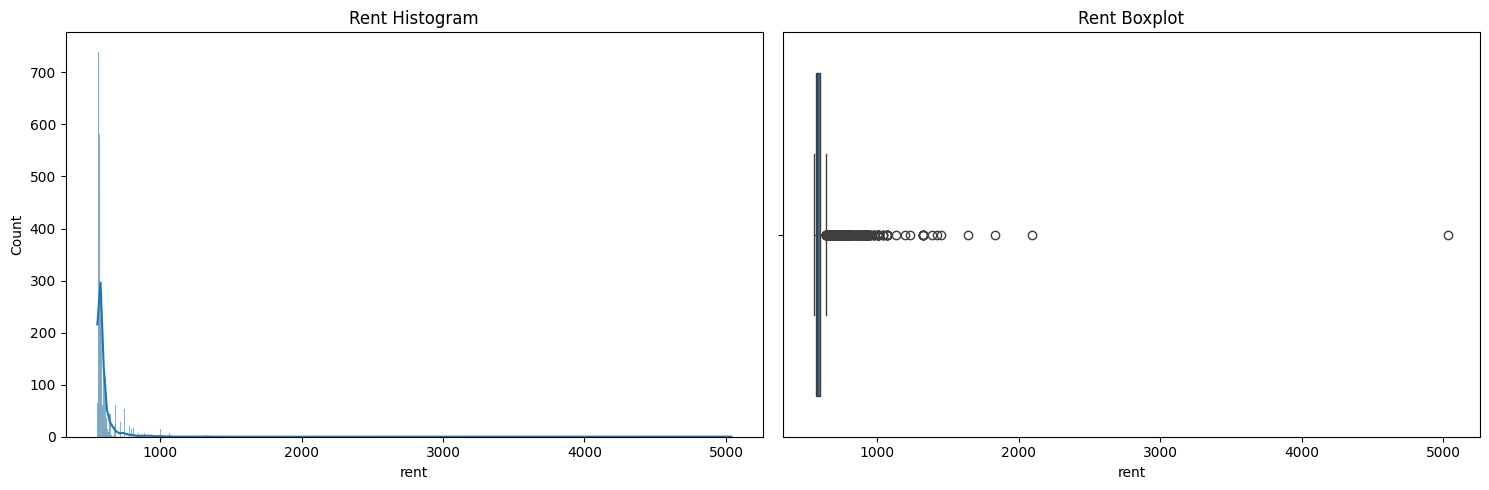

In [ ]:
# Histogram and Boxplot for target variable in 3 set
# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot histogram and boxplot for target variable in the combined dataset
sns.histplot(df[target_name], kde=True, ax=ax[0])
ax[0].set_title('Rent Histogram')
sns.boxplot(x=df[target_name], ax=ax[1])
ax[1].set_title('Rent Boxplot')

# adjust layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Check skewness of 'rent' to see if a transformation is needed
skewness = df[target_name].skew()
print(f"Skewness of Rent: {skewness}")

Skewness of Rent: 20.95438315624619


### A.6 Explore Feature of Interest

> You can add more cells in this section

####A.6.1 Categorical Variables

In [ ]:
# Select all the categorical feature
cat_col = training_df.select_dtypes(include=['object']).columns
cat_col

Index(['advertised_date', 'level', 'suburb', 'furnished', 'tenancy_preference',
       'point_of_contact', 'secondary_address', 'street_name', 'street_suffix',
       'prefix', 'first_name', 'last_name', 'gender', 'phone_number', 'email'],
      dtype='object')

#####A.6.1a Personal Information Variables

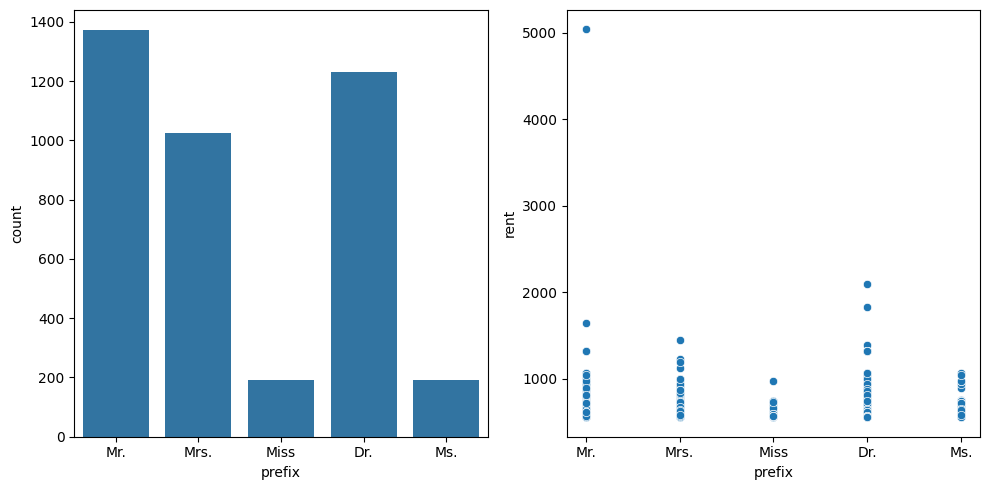

In [ ]:
# Visualize the prefix variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Count plot
sns.countplot(x=df['prefix'].reset_index(drop=True), ax=ax[0])
# Scatter plot
sns.scatterplot(x=df['prefix'].reset_index(drop=True), y=df[target_name].reset_index(drop=True), ax=ax[1], )

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There is 5 unique values of prefix column. "Mr" and "Dr" are the most common prefixes, with counts around 1,200-1,300. "Mrs" also has a fairly high count (around 1,000), followed by "Miss" and "Ms," which are around 200.

For prefixes like "Mr" and "Dr" there are a few higher rent outliers, but most rent values seem to fall below 2,000. "Mrs", "Miss" and "Ms" prefixes have a more consistent and lower range of rent values.

However, in the reality, the prefix is not effect on the rental prices. It could be that those who have properties collected in these dataset are mainly "Mr", and "Dr".

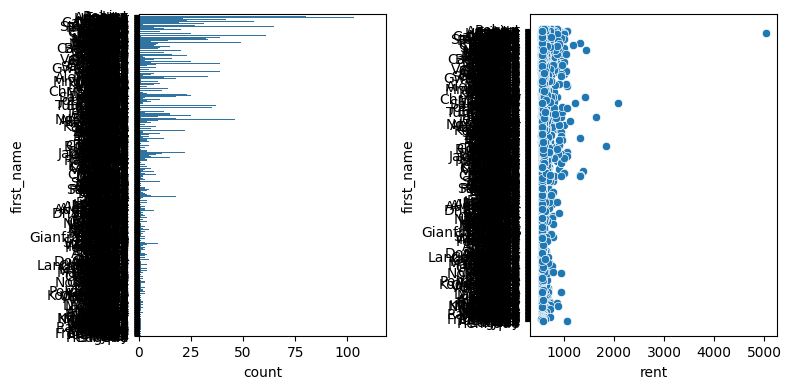

In [ ]:
# Visualize the first_name variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
sns.countplot(y=df['first_name'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['first_name'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There are too many unique values of first_name variable. The plot indicates that there is no clear linear relationship between first names and rent values. Therefore, "first_name" does not seem to impact the relationship with rent.

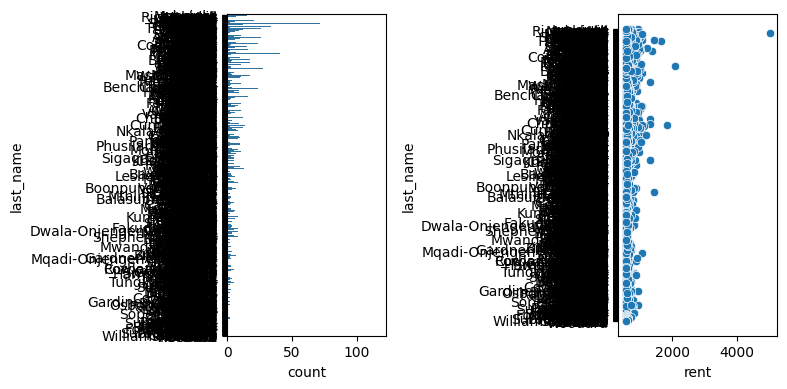

In [ ]:
# Visualize the last_name variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8,4))

# Count plot
sns.countplot(y=df['last_name'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['last_name'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: Like the first_name column, there are too many unique values of last_name variable. The plot indicates that there is no clear linear relationship between last names and rent values. Therefore, "last_name" does not seem to impact the relationship with rent.

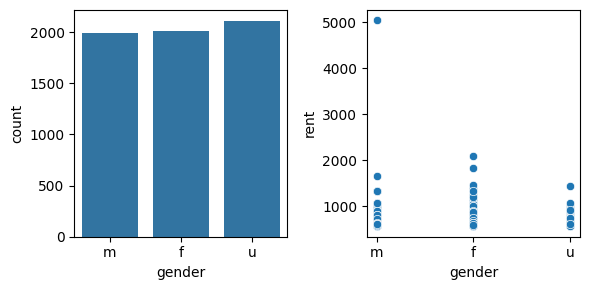

In [ ]:
# Visualize the gender variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Count plot
sns.countplot(x=df['gender'].reset_index(drop=True), ax=ax[0])
# Scatter plot
sns.scatterplot(x=df['gender'].reset_index(drop=True), y=df[target_name].reset_index(drop=True), ax=ax[1], )

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There are 3 unique values of gender column. Male, female and unknown doesn't have significant difference in distribution.

However, in the reality the gender does not impact significantly the rent.

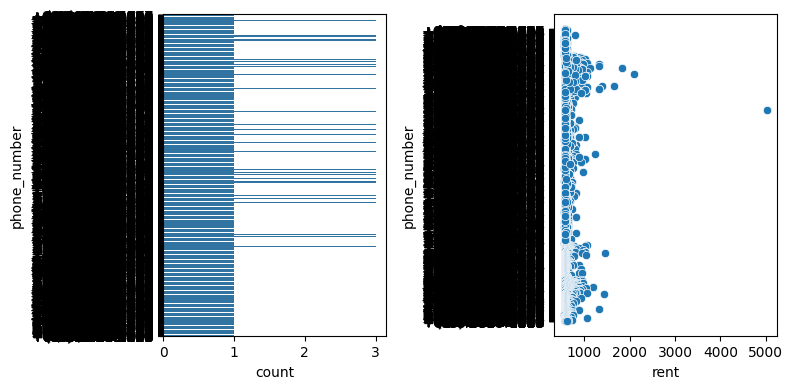

In [ ]:
# Visualize the phone_number variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
sns.countplot(y=df['phone_number'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['phone_number'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There are too many unique values of phone_number variable. The plot indicates that there is no clear linear relationship between phone numbers and rent values. Therefore, "phone_number" does not seem to impact the relationship with rent.

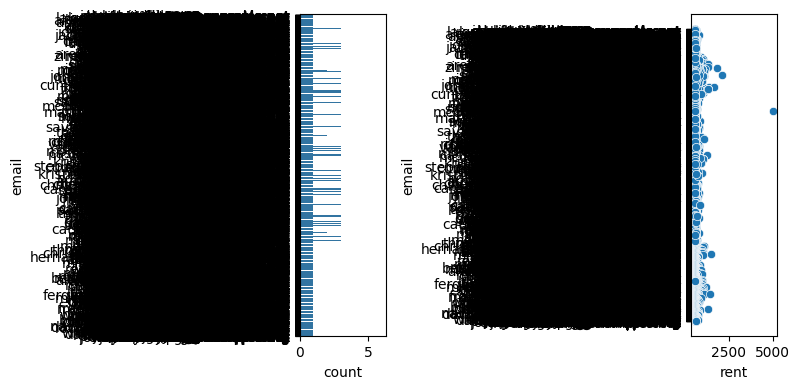

In [ ]:
# Visualize the email variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
sns.countplot(y=df['email'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['email'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There are too many unique values of email variable. The plot indicates that there is no clear linear relationship between email and rent values. Therefore, "email" does not seem to impact the relationship with rent.

#####A.6.1b Housing Information Variables

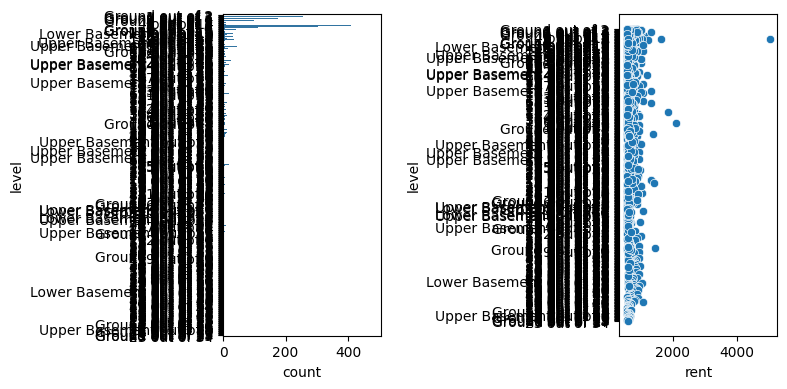

In [ ]:
# Visualize the level variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
sns.countplot(y=df['level'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['level'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: The distribution shows that the "level" feature is imbalance, which should be handled during modeling. Rent values distribute across all levels, with some higher rent outliers, particularly for certain levels.

Some levels might be associated with higher rent ranges, suggesting that there could be some relationship between "level" and rent.

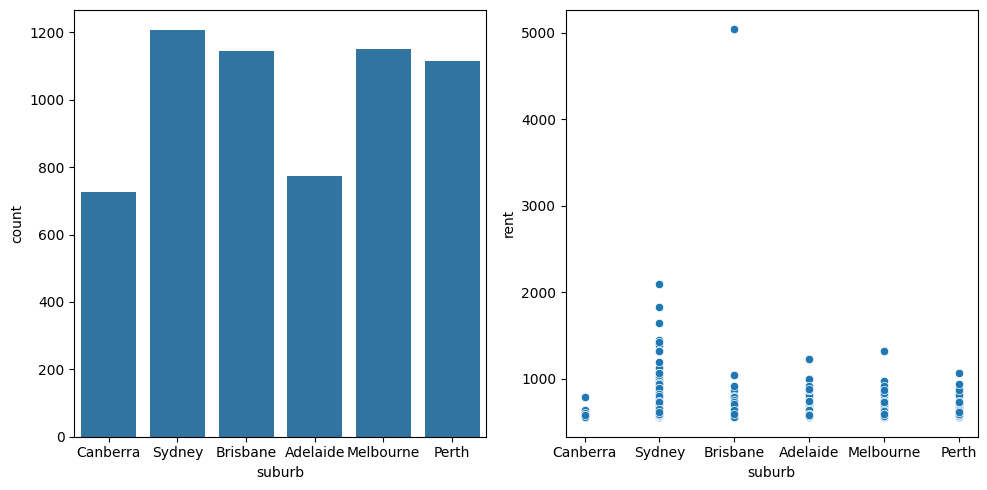

In [ ]:
# Visualize the suburb variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Count plot
sns.countplot(x=df['suburb'].reset_index(drop=True), ax=ax[0])
# Scatter plot
sns.scatterplot(x=df['suburb'].reset_index(drop=True), y=df[target_name].reset_index(drop=True), ax=ax[1], )

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: The distribution indicates that some suburbs such as Sydney, Brisbane, Melbourne and Perth are overrepresented in the dataset, while others are underrepresented.

The scatterplot shows that Sydney has the widest rent range, including several high-rent listings above \$2,000, suggesting that Sydney has a mix of mid-range and luxury rentals, making it one of the most expensive and diverse rental prices in the dataset.

While Brisbane, Adelaide, Melbourne, and Perth tend to have more affordable and consistent rental pricing, mostly under $1,200.

Canberra shows the lowest rent range overall, with most properties renting for under $1,000, suggesting a lower cost of living or smaller average property sizes in that area.


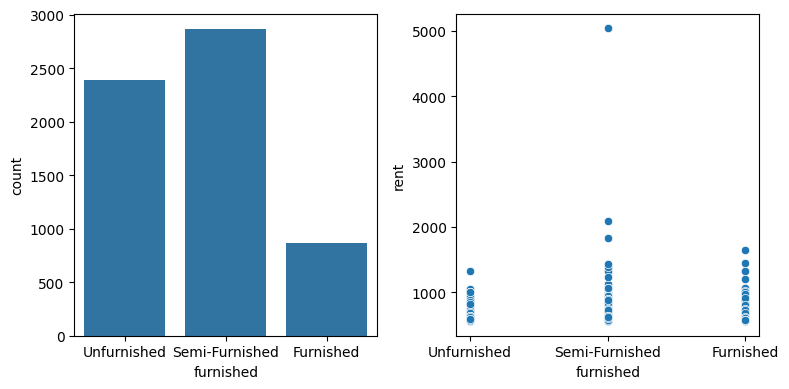

In [ ]:
# Visualize the furnished variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
sns.countplot(x=df['furnished'].reset_index(drop=True), ax=ax[0])
# Scatter plot
sns.scatterplot(x=df['furnished'].reset_index(drop=True), y=df[target_name].reset_index(drop=True), ax=ax[1], )

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: The distribution indicates that Unfurnished, and Semi-Furnished are overrepresented in the dataset, while Furnished is underrepresented. Most of the rent values across "furnished" appear to fall below 2,000, with some outliers present in Semi_Furnished.

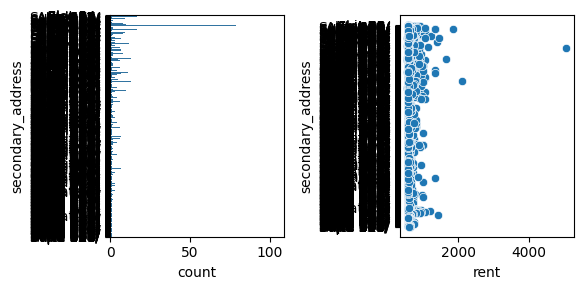

In [ ]:
# Visualize the secondary_address variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Count plot
sns.countplot(y=df['secondary_address'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['secondary_address'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There are too many unique values of secondary_address variable. The plot indicates that there is no clear linear relationship between secondary_address and rent values. Therefore, "secondary_address" does not seem to impact the relationship with rent.

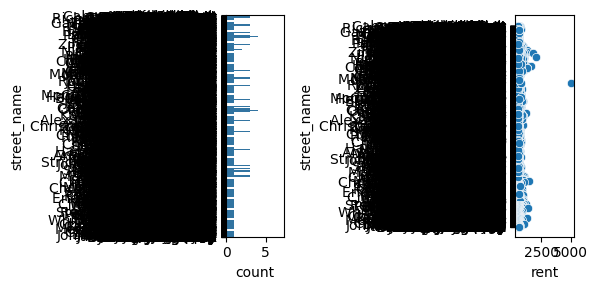

In [ ]:
# Visualize the street_name variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Count plot
sns.countplot(y=df['street_name'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['street_name'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: There are too many unique values of street_name variable. The plot indicates that there is no clear linear relationship between street name and rent values. Therefore, "street_name" does not seem to impact the relationship with rent.

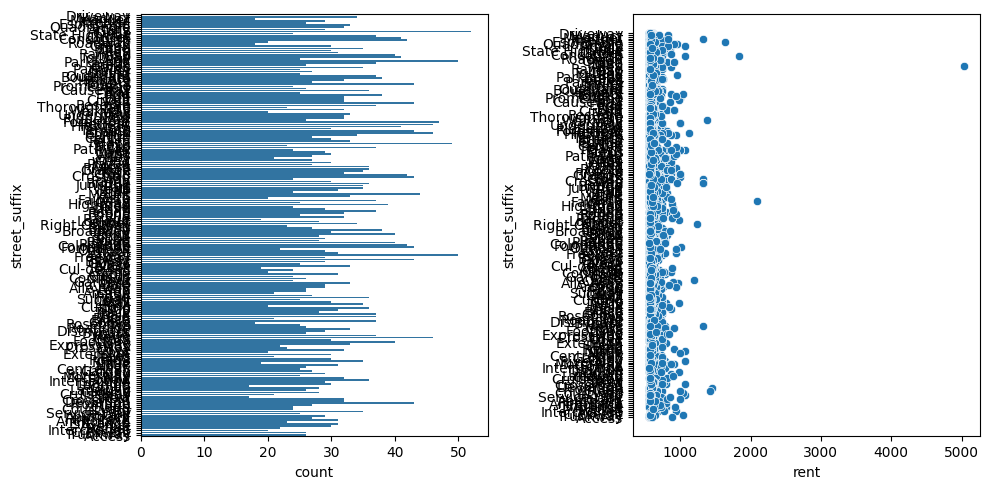

In [ ]:
# Visualize the street_suffix variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Count plot
sns.countplot(y=df['street_suffix'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['street_suffix'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: Some suffixes like "St" and "Ave" have higher frequencies, suggesting that many street names are associated with these common suffixes.

The Scatterplot shows that rent values are spread across a wide range, with some outliers above 2,000. However, there doesn't seem to be any clear pattern or trend between "street_suffix" and rent. Therefore, in the feature selection, we should use ANOVA test to consider this variable.

#####A.6.1c Advertisedment-related and Tenant-related Variables

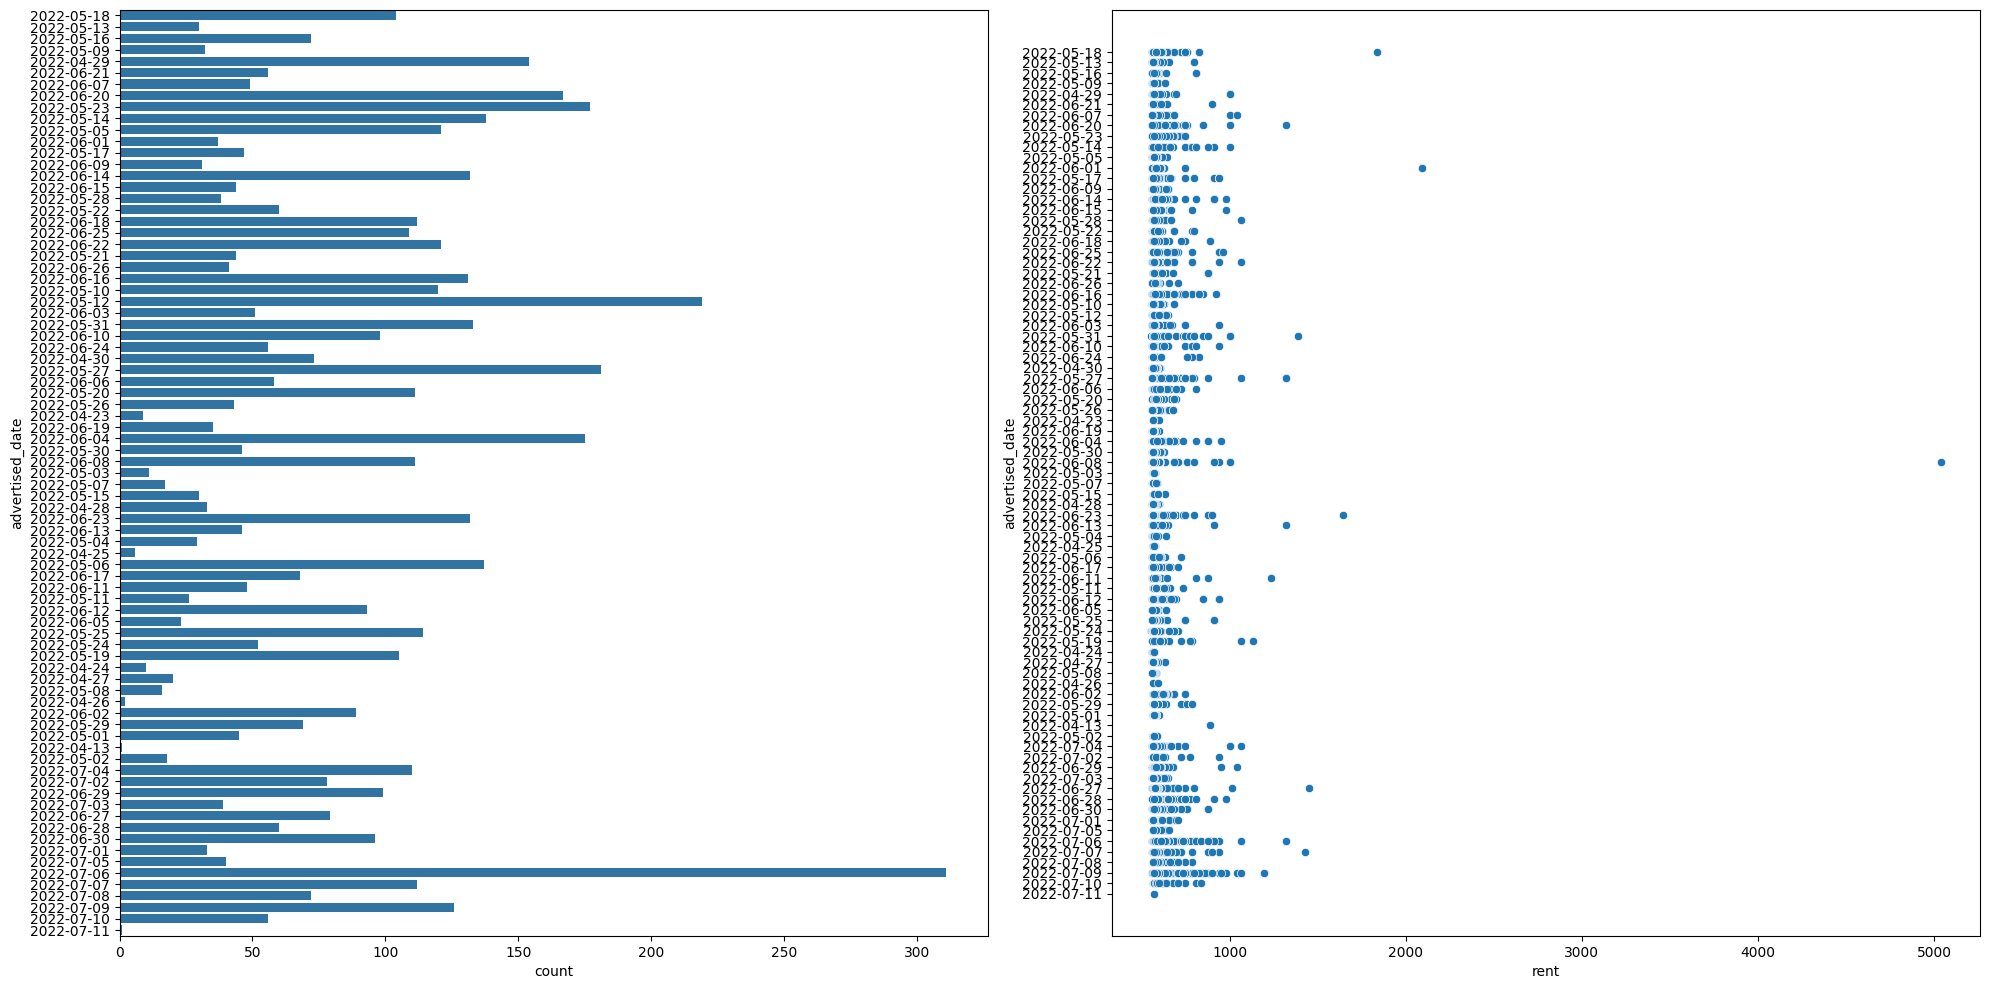

In [ ]:
# Visualize the advertised_date variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count plot
sns.countplot(y=df['advertised_date'].reset_index(drop=True), ax=ax[0])

# Scatter plot
sns.scatterplot(y=df['advertised_date'].reset_index(drop=True), x=df[target_name].reset_index(drop=True), ax=ax[1])

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: The bar chart shows the distribution of the date of posting advertisement. In April, there were few advertisements posted. However, it increased in May and June, and rose significantly in July, such as on 2022-07-06, there were over 300 advertisement posts.

The scatterplot shows that the rent prices maybe follow an upward trend over month. In particular, in July, such as on 2022-07-06 and 2022-07-09, the rent prices were mostly from \$400 to over \$1,000.

This suggests that July can be the begining month of the Spring semester, which leads to the increase in rental prices due to the demand of both domestic and international students.


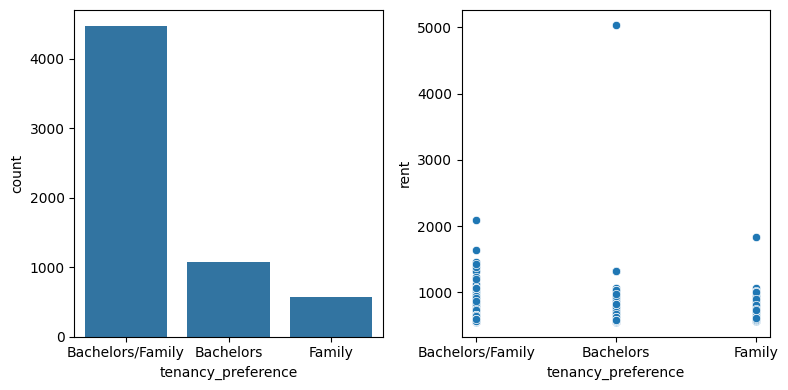

In [ ]:
# Visualize the tenancy_preference variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
sns.countplot(x=df['tenancy_preference'].reset_index(drop=True), ax=ax[0])
# Scatter plot
sns.scatterplot(x=df['tenancy_preference'].reset_index(drop=True), y=df[target_name].reset_index(drop=True), ax=ax[1], )

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: The bar chart shows that Bachelors/Family is the most tenancy prefer of the landloards or agents, with the frequeny over 4,000. While the Bachelors and Family have 1,000 and around 500 observations, respectively.

However, the scatter indicates that the Bachelors and Family do not have difference in the rent prices (mostly from \$500 to \$1,000), while the Bachelors/Family will pay more a little bit (from \$500 to \$1,500).

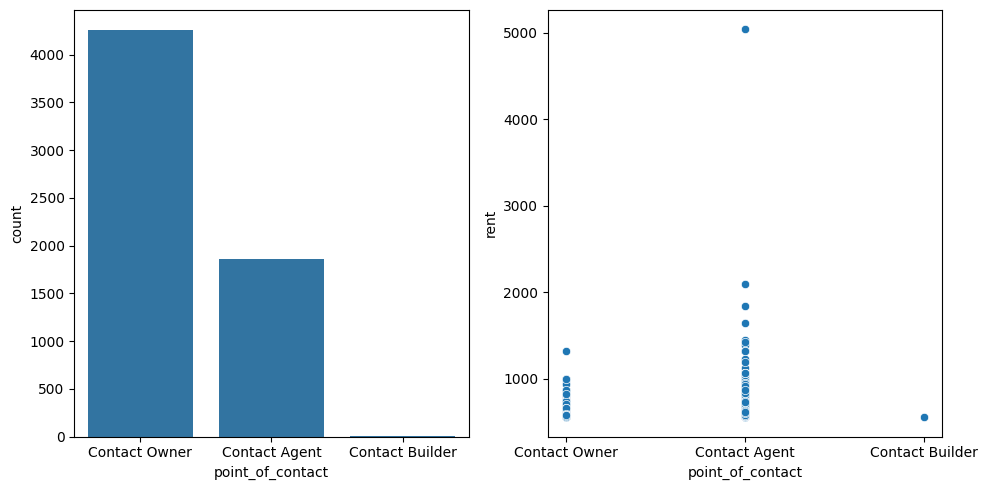

In [ ]:
# Visualize the point_of_contact variable with count and scatter plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Count plot
sns.countplot(x=df['point_of_contact'].reset_index(drop=True), ax=ax[0])
# Scatter plot
sns.scatterplot(x=df['point_of_contact'].reset_index(drop=True), y=df[target_name].reset_index(drop=True), ax=ax[1], )

# Display the plots
plt.tight_layout()
plt.show()

**Insights**: The bar chart shows that the contact_owner has the most appearance with over 4,000 observations, while the contact_agent is approximately less than two times.

However, the scatterplot indicates that, with the higher rent prices (some listings above $5,000), agents might handle more premium or high-value properties.

Contact Owner listings tend to have the lower to mid rent range, mainly below $1,500.

The one Contact Builder listing has a rent value around $500, but it is not statistically significant because of the very small sample size.

####A.6.2 Numerical Variables



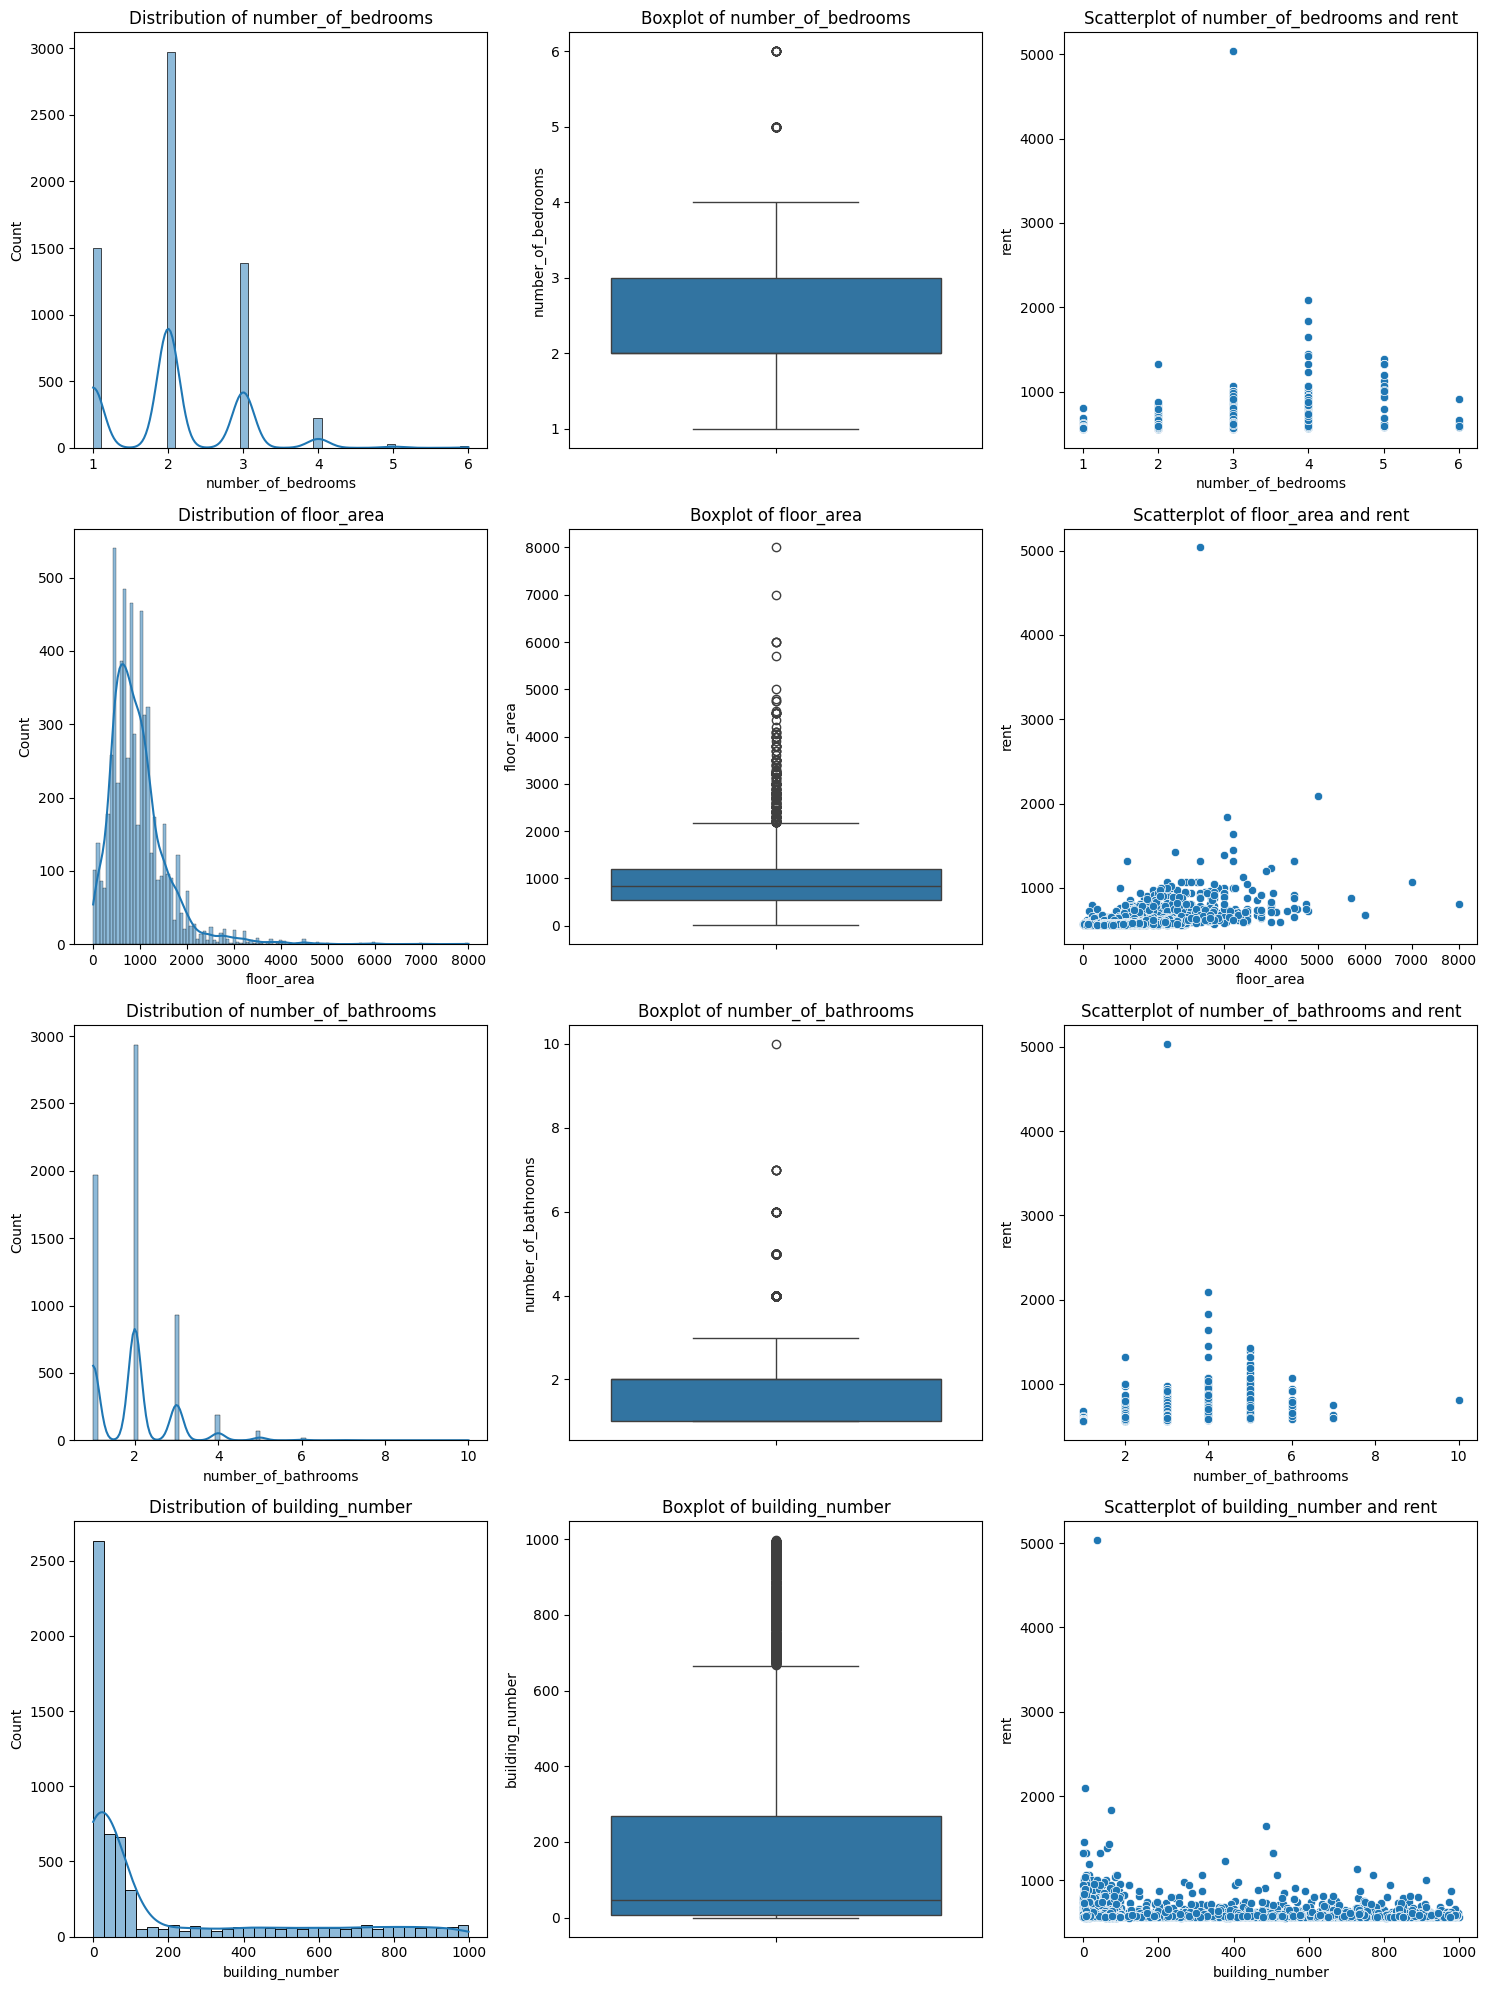

In [ ]:
# Create a numerical variable list
num_col = df.select_dtypes(include=['int64', 'float64']).columns
num_col = [col for col in num_col if col != 'rent']

# Number of rows
nrows = len(num_col)

# Create subplots
fig, ax = plt.subplots(nrows, 3, figsize=(15, 5 * nrows))

# Flatten the axes array for easier indexing
ax = ax.flatten()

# Iterate over each score variable and corresponding axes
for i, col in enumerate(num_col):
    # Plot histogram with KDE on the first column
    sns.histplot(df[col], kde=True, ax=ax[i * 3])
    ax[i * 3].set_title(f"Distribution of {col}")

    # Plot boxplot on the second column
    sns.boxplot(y=df[col], ax=ax[i * 3 + 1])
    ax[i * 3 + 1].set_title(f"Boxplot of {col}")

    # Plot scatterplot against the target variable on the third column
    sns.scatterplot(x=df[col], y=df[target_name], ax=ax[i * 3 + 2])
    ax[i * 3 + 2].set_title(f"Scatterplot of {col} and {target_name}")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

---
## B. Feature Selection


### B.1 Approach 1

In [ ]:
from scipy.stats import f_oneway
# List of numerical columns to compare with street_suffix
numeric_cols = [
    'rent',
    'floor_area',
    'number_of_bedrooms',
    'number_of_bathrooms',
    'building_number'
]

# Create a clean DataFrame with required columns
df1 = training_df[['street_suffix'] + numeric_cols].dropna()

# Store results
anova_results = {}

# Loop through numeric columns and run ANOVA
for col in numeric_cols:
    # Group the data by street_suffix
    groups = [group[col].values for _, group in df1.groupby('street_suffix')]

    # Only test if there are at least 2 groups with data
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {
            'F-statistic': f_stat,
            'p-value': p_val
        }

# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(anova_results).T
results_df = results_df.sort_values('p-value')

# Display results
display("ANOVA Results:\n")
display(results_df)

'ANOVA Results:\n'

,F-statistic,p-value
rent,0.947096,0.688430
floor_area,0.933600,0.734939
building_number,0.923041,0.768987
number_of_bedrooms,0.876415,0.889106
number_of_bathrooms,0.856089,0.924998


### B.2 Approach 2

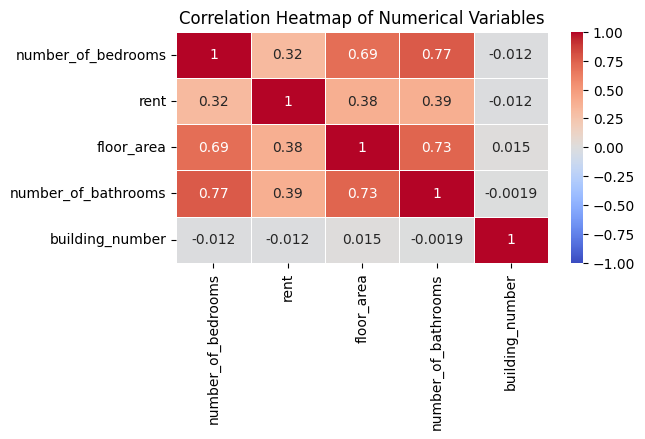

In [ ]:
numerical_columns = training_df.select_dtypes(include=['int64', 'float64']).columns.tolist() # Re-initialize numerical_columns

# Calculate the correlation matrix between numerical variables and 'y'
correlation_matrix = training_df[numerical_columns].corr()

# Create the heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### B.3 Final Selection of Features

> Save the names of selected features into a list called `features_list`

In [ ]:
features_list = ["advertised_date", "number_of_bedrooms", "rent", "floor_area", "level", "suburb", "furnished", "tenancy_preference", "number_of_bathrooms", "point_of_contact"]

---
## C. Data Cleaning

### C.1 Copy Datasets

> Create copies of the datasets and called them `training_df_clean`, `validation_df_clean` and `testing_df_clean`

> Do not change this code

In [ ]:
# Create copy of datasets

training_df_clean = training_df[features_list].copy()
validation_df_clean = validation_df[features_list].copy()
testing_df_clean = testing_df[features_list].copy()

### C.2 Fixing "combine Contact Builder and Contact Agent"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [ ]:
training_df_clean['point_of_contact'].value_counts()

,count
point_of_contact,
Contact Owner,2555
Contact Agent,878
Contact Builder,1


In [ ]:
# Replace 'Contact Builder' with 'Contact Agent'
training_df_clean['point_of_contact'] = training_df_clean['point_of_contact'].replace('Contact Builder', 'Contact Agent')

# Verify the result
training_df_clean['point_of_contact'].value_counts()

,count
point_of_contact,
Contact Owner,2555
Contact Agent,879


### C.3 Fixing "remove one outlier from number_of_bathrooms feature"

> Provide some explanations on why you believe it is important to fix this issue and its impacts

> You can add more cells in this section

In [ ]:
training_df['number_of_bathrooms'].value_counts()

,count
number_of_bathrooms,
2,1642
1,1194
3,469
4,86
5,33
6,7
7,2
10,1


In [ ]:
# Filter the DataFrame to keep rows where 'number_of_bathrooms' is not 10
training_df_clean = training_df_clean[training_df_clean['number_of_bathrooms'] != 10]

# Verify the result
training_df_clean['number_of_bathrooms'].value_counts()

,count
number_of_bathrooms,
2,1642
1,1194
3,469
4,86
5,33
6,7
7,2


---
## D. Feature Engineering

### D.1 Copy Datasets

> Create copies of the datasets and called them `training_df_eng`, `validation_df_eng` and `testing_df_eng`

> Do not change this code

In [ ]:
# Create copy of datasets

training_df_eng = training_df_clean.copy()
validation_df_eng = validation_df_clean.copy()
testing_df_eng = testing_df_clean.copy()

### D.2 New Feature "level"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [ ]:
# Function to extract the floor level from the 'level' column
def extract_floor_level(level):
    # Check if the word "Ground" and "Basement" is in the level description
    if any(word in level for word in ['Ground', 'Basement']): # Fix: Check for each word individually
      return 0
    # Extract the first number before "out of"
    try:
        return int(level.split(' ')[0])
    except Exception as e:
        return None  # In case of any unexpected format

# Apply the function to convert 'level' into a numerical column
training_df_eng['level'] = training_df_eng['level'].apply(extract_floor_level)
validation_df_eng['level'] = validation_df_eng['level'].apply(extract_floor_level)
testing_df_eng['level'] = testing_df_eng['level'].apply(extract_floor_level)



# Show the updated dataframe with the new numerical 'level' column
training_df_eng[['level']].head(100)
validation_df_eng[['level']].head(100)

,level
0,0
1,0
2,0
3,2
4,2
...,...
95,0
96,4
97,1
98,1


In [ ]:
# Function to categorize the 'level' into 'Low', 'Medium', and 'High'
def categorize_level(level):
    if level <= 10:
        return 'Low'
    elif 11 <= level <= 20:
        return 'Medium'
    else:
        return 'High'

# Apply the function to create a new 'level_group' column
training_df_eng['level'] = training_df_eng['level'].apply(categorize_level)
validation_df_eng['level'] = validation_df_eng['level'].apply(categorize_level)
testing_df_eng['level'] = testing_df_eng['level'].apply(categorize_level)

# Show the updated dataframe with the new 'level_group' column
training_df_eng['level'].head(100)

,level
0,Low
1,Low
2,Low
3,Low
4,Low
...,...
95,Low
96,Low
97,Low
98,Low


### D.3 New Feature "advertised_month"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [ ]:
# extract the month and convert advertised_date to ['advertised_month'], errors='coerce')
training_df_eng['advertised_date'] = pd.to_datetime(training_df_eng['advertised_date'], errors='coerce')
training_df_eng['advertised_month'] = training_df_eng['advertised_date'].dt.month
validation_df_eng['advertised_date'] = pd.to_datetime(validation_df_eng['advertised_date'], errors='coerce')
validation_df_eng['advertised_month'] = validation_df_eng['advertised_date'].dt.month
testing_df_eng['advertised_date'] = pd.to_datetime(testing_df_eng['advertised_date'], errors='coerce')
testing_df_eng['advertised_month'] = testing_df_eng['advertised_date'].dt.month

# Drop 'advertised_date' out of the dataframe
training_df_eng = training_df_eng.drop(columns=['advertised_date'])
validation_df_eng = validation_df_eng.drop(columns=['advertised_date'])
testing_df_eng = testing_df_eng.drop(columns=['advertised_date'])

# Show the updated dataframe
training_df_eng[['advertised_month']].head(100)

,advertised_month
0,5
1,5
2,5
3,5
4,4
...,...
95,5
96,4
97,5
98,5


---
## E. Data Preparation for Modeling

### E.1 Copy Datasets

> Create copies of the datasets and split them into X and y

> Do not change this code

In [ ]:
# Create copy of datasets

X_train = training_df_eng.copy()
X_val = validation_df_eng.copy()
X_test = testing_df_eng.copy()

y_train = X_train.pop(target_name)
y_val = X_val.pop(target_name)
y_test = X_test.pop(target_name)

### E.2 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# One-Hot Encoding for categorical features on the training set
X_train = pd.get_dummies(X_train, columns=['suburb', 'furnished', 'tenancy_preference', 'point_of_contact', 'level'], drop_first=True)

# Apply One-Hot Encoding to the validation and test sets, ensuring columns match the training set
X_val = pd.get_dummies(X_val, columns=['suburb', 'furnished', 'tenancy_preference', 'point_of_contact', 'level'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['suburb', 'furnished', 'tenancy_preference', 'point_of_contact', 'level'], drop_first=True)

# Ensure the columns of the test and validation sets match the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Check the first few rows of the encoded training set
X_train.head()

,number_of_bedrooms,floor_area,number_of_bathrooms,advertised_month,suburb_Brisbane,suburb_Canberra,suburb_Melbourne,suburb_Perth,suburb_Sydney,furnished_Semi-Furnished,furnished_Unfurnished,tenancy_preference_Bachelors/Family,tenancy_preference_Family,point_of_contact_Contact Owner,level_Low,level_Medium
0,2,1100,2,5,False,True,False,False,False,False,True,True,False,True,True,False
1,2,800,1,5,False,True,False,False,False,True,False,True,False,True,True,False
2,2,1000,1,5,False,True,False,False,False,True,False,True,False,True,True,False
3,2,850,1,5,False,True,False,False,False,False,True,False,False,True,True,False
4,2,600,2,4,False,True,False,False,False,False,True,True,False,True,True,False


### E.3 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


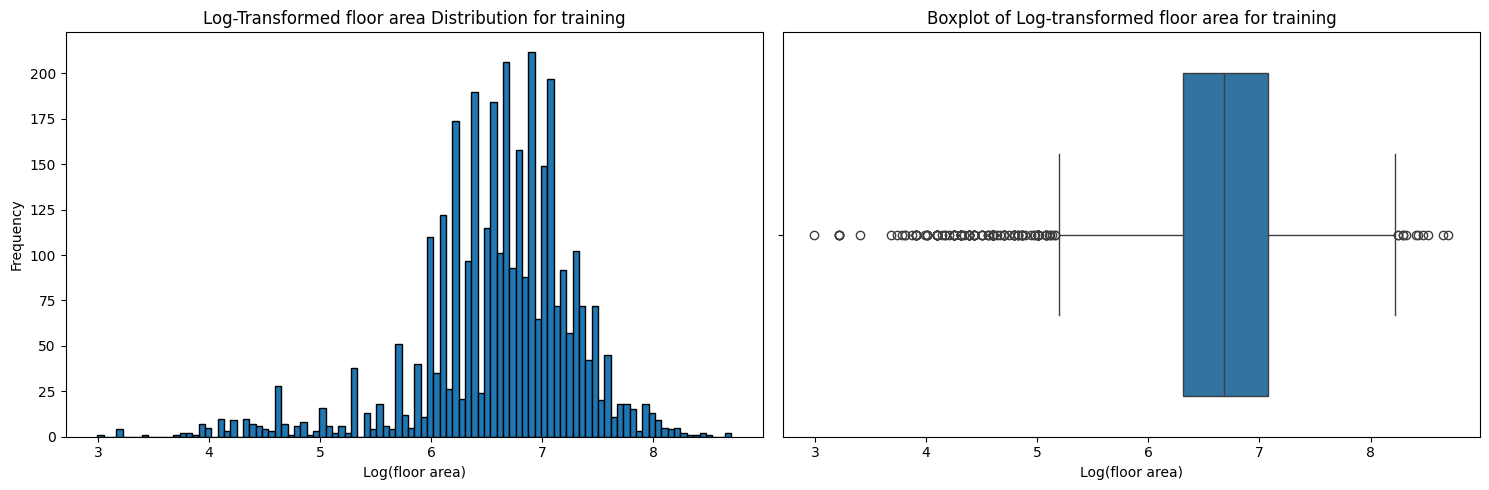

In [ ]:
# Apply log transformation to 'floor_area'
X_train['log_floor_area'] = np.log(X_train['floor_area'])
X_val['log_floor_area'] = np.log(X_val['floor_area'])
X_test['log_floor_area'] = np.log(X_test['floor_area'])

# Create a figure with two subplots in the same line
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram for the log-transformed 'floor_area'
ax[0].hist(X_train['log_floor_area'], bins=100, edgecolor='black')
ax[0].set_title('Log-Transformed floor area Distribution for training')
ax[0].set_xlabel('Log(floor area)')
ax[0].set_ylabel('Frequency')

# 2. Boxplot for the log-transformed 'floor_area'
sns.boxplot(x=X_train['log_floor_area'], ax=ax[1])
ax[1].set_title('Boxplot of Log-transformed floor area for training')
ax[1].set_xlabel('Log(floor area)')

# Adjust layout to ensure the plots are well spaced
plt.tight_layout()
plt.show()

In [ ]:
X_train.drop(['floor_area'], axis=1, inplace=True)
X_val.drop(['floor_area'], axis=1, inplace=True)
X_test.drop(['floor_area'], axis=1, inplace=True)

# Check the updated dataframe
X_train.head()

,number_of_bedrooms,number_of_bathrooms,advertised_month,suburb_Brisbane,suburb_Canberra,suburb_Melbourne,suburb_Perth,suburb_Sydney,furnished_Semi-Furnished,furnished_Unfurnished,tenancy_preference_Bachelors/Family,tenancy_preference_Family,point_of_contact_Contact Owner,level_Low,level_Medium,log_floor_area
0,2,2,5,False,True,False,False,False,False,True,True,False,True,True,False,7.003065
1,2,1,5,False,True,False,False,False,True,False,True,False,True,True,False,6.684612
2,2,1,5,False,True,False,False,False,True,False,True,False,True,True,False,6.907755
3,2,1,5,False,True,False,False,False,False,True,False,False,True,True,False,6.745236
4,2,2,4,False,True,False,False,False,False,True,True,False,True,True,False,6.396930


### E.4 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
#import min max scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply min max scaler for train, validation and test set
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#Re-assign the result to X_train, X_val, X_test
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
X_train.describe()

,number_of_bedrooms,number_of_bathrooms,advertised_month,suburb_Brisbane,suburb_Canberra,suburb_Melbourne,suburb_Perth,suburb_Sydney,furnished_Semi-Furnished,furnished_Unfurnished,tenancy_preference_Bachelors/Family,tenancy_preference_Family,point_of_contact_Contact Owner,level_Low,level_Medium,log_floor_area
count,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3433.000000,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03,3.433000e+03
mean,-1.821374e-16,4.139486e-17,-2.566481e-16,1.655794e-16,0.000000,9.934766e-17,-1.655794e-16,-6.623177e-17,4.967383e-17,-1.283241e-16,-1.655794e-17,2.069743e-17,2.152533e-16,1.655794e-17,4.967383e-17,7.616654e-16
std,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00,1.000146e+00
min,-1.257648e+00,-1.047675e+00,-2.271301e+00,-5.033658e-01,-0.382418,-4.750092e-01,-4.574151e-01,-4.634557e-01,-9.271983e-01,-8.144171e-01,-1.736434e+00,-3.037574e-01,-1.704575e+00,-4.086059e+00,-2.152379e-01,-5.100192e+00
25%,-1.257648e+00,-1.047675e+00,-6.224586e-01,-5.033658e-01,-0.382418,-4.750092e-01,-4.574151e-01,-4.634557e-01,-9.271983e-01,-8.144171e-01,5.758927e-01,-3.037574e-01,-1.704575e+00,2.447346e-01,-2.152379e-01,-4.324375e-01
50%,-2.793978e-02,1.444591e-01,-6.224586e-01,-5.033658e-01,-0.382418,-4.750092e-01,-4.574151e-01,-4.634557e-01,-9.271983e-01,-8.144171e-01,5.758927e-01,-3.037574e-01,5.866566e-01,2.447346e-01,-2.152379e-01,9.528695e-02
75%,-2.793978e-02,1.444591e-01,1.026384e+00,-5.033658e-01,-0.382418,-4.750092e-01,-4.574151e-01,-4.634557e-01,1.078518e+00,1.227872e+00,5.758927e-01,-3.037574e-01,5.866566e-01,2.447346e-01,-2.152379e-01,6.426793e-01
max,4.890894e+00,6.105131e+00,1.026384e+00,1.986627e+00,2.614938,2.105223e+00,2.186198e+00,2.157703e+00,1.078518e+00,1.227872e+00,5.758927e-01,3.292101e+00,5.866566e-01,2.447346e-01,4.646023e+00,2.933110e+00


---
## F. Save Datasets

> Do not change this code

In [ ]:
# Save training set

X_train.to_csv(folder_path / 'X_train.csv', index=False)
y_train.to_csv(folder_path / 'y_train.csv', index=False)

In [ ]:
# Save validation set

X_val.to_csv(folder_path / 'X_val.csv', index=False)
y_val.to_csv(folder_path / 'y_val.csv', index=False)

In [ ]:
# Save testing set

X_test.to_csv(folder_path / 'X_test.csv', index=False)
y_test.to_csv(folder_path / 'y_test.csv', index=False)

---
## G. Assess Baseline Model

### G.1 Generate Predictions with Baseline Model

In [ ]:
# Define central value for baseline model
y_central = y_train.mean()

# Create numpy array filled with y_central value have the same dimensions with y_train
training_preds = np.full_like(y_train, y_central)
val_preds = np.full_like(y_val, y_central)
test_preds = np.full_like(y_test, y_central)

### G.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

### G.3 Baseline Model Performance

> Provide some explanations on model performance


In [ ]:
#Baseline performance on Training
# Calculate MSE, and RMSE
train_mse = mse(y_train, training_preds)
train_rmse = rmse(y_train, training_preds)

print(f'MSE of Training set: {train_mse}')
print(f'RMSE of Training set: {train_rmse}')

MSE of Training set: 11091.529832830865
RMSE of Training set: 105.31633222264658


In [ ]:
# Baseline performance on Validation
# Calculate MSE, and RMSE
val_mse = mse(y_val, val_preds)
val_rmse = rmse(y_val, val_preds)

print(f'MSE of Validation set: {val_mse}')
print(f'RMSE of Validation set: {val_rmse}')

MSE of Validation set: 4618.936442359135
RMSE of Validation set: 67.9627577601081


In [ ]:
# Baseline performance on Testing
# Calculate MAE, MSE, and RMSE
test_mse = mse(y_test, test_preds)
test_rmse = rmse(y_test, test_preds)

print(f'MSE of Testing set: {test_mse}')
print(f'RMSE of Testing set: {test_rmse}')

MSE of Testing set: 6544.872239773058
RMSE of Testing set: 80.90038467011797


In [ ]:
perfect_test = alt.Chart(pd.DataFrame({'target': y_train, 'preds': y_train})).mark_line(color='green').encode(
    x='target',
    y='preds'
)

pred_chart_test = alt.Chart(pd.DataFrame({'target': y_train, 'preds': training_preds})).mark_line().encode(
    x='target',
    y='preds'
  )

pred_chart_test + perfect_test

alt.LayerChart(...)